<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/main/LightGBM_Regerssor_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import shap

drive.mount('/content/drive')
path = "/content/drive/MyDrive/model_df_clf_v2.feather"
data = pd.read_feather(path)

print(data.shape)
data.info()


#Convert numerical, drop data with missing LOS, & drop patients with 'OOS' zip code
data['length_of_stay'] = pd.to_numeric(data['length_of_stay'], errors='coerce')
data = data.dropna(subset=['length_of_stay'])
data = data[data['zip_code'] != 'OOS']



#Creating log-transformed LOS (target variable)
data['los_log'] = np.log1p(data['length_of_stay'])



#Categorical Features
categorical_cols = ['health_service_area', 'facility_id', 'zip_code', 'hospital_county',
                    'age_group', 'gender', 'race', 'ethnicity', 'admission_type',
                    'apr_mortality_risk','apr_severity_code', 'apr_drg_code', 'apr_med_surg_desc',
                    'apr_mdc_code', 'ccsr_dx_code', 'ccsr_px_code', 'payment_type']
feature_cols = categorical_cols + ['num_payment_types']

#Convert categorical columns to category dtype
for col in categorical_cols:
  if col in data.columns:
    data[col] = data[col].astype('category')



# Define features and target
X = data[feature_cols]
y = data['los_log']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# LightGBM Regressor (memory-efficient and fast)
model = lgb.LGBMRegressor(n_estimators = 1000, learning_rate = 0.03, num_leaves = 63,
                          max_depth = -1, subsample = 0.8, colsample_bytree = 0.8,
                          n_jobs = -1, random_state = 42)
# Train the model
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)



# Evaluate Log Data
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(4238636, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238636 entries, 0 to 4238635
Data columns (total 20 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   health_service_area  object
 1   hospital_county      object
 2   facility_id          object
 3   age_group            object
 4   zip_code             object
 5   gender               object
 6   race                 object
 7   ethnicity            object
 8   length_of_stay       int64 
 9   admission_type       object
 10  ccsr_dx_code         object
 11  ccsr_px_code         object
 12  apr_drg_code         object
 13  apr_mdc_code         object
 14  apr_severity_code    object
 15  apr_mortality_risk   object
 16  apr_med_surg_desc    object
 17  num_payment_types    int64 
 18  payment_type         object
 19  los_category         object
dtypes: int64(2), 

In [4]:
#Predicting log Scale
y_pred_log = model.predict(X)

#Converting predictions back to original LOS
y_pred = np.expm1(y_pred_log)

y_true = data['length_of_stay'].values

#Using 20 rows for predicting
print("Predicted LOS:", y_pred[:20])
print("True LOS:", y_true[:20])

Predicted LOS: [3.25340846 2.20685848 8.39353338 3.03940453 4.55720649 2.71713031
 1.84375687 2.13899062 2.62057242 3.2178085  2.20705747 2.36066561
 2.94441533 2.5252844  2.77015368 1.51776897 2.34885114 3.78371836
 1.53287574 2.10704839]
True LOS: [1 4 4 5 3 1 1 1 3 3 2 1 3 3 3 1 3 5 1 1]


In [5]:
#LOG-Transformed Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.3f}")

print(f"Original Scale -> MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

MAE: 2.72
RMSE: 6.59
R2: 0.431
Original Scale -> MAE: 2.721, RMSE: 6.585, R²: 0.431


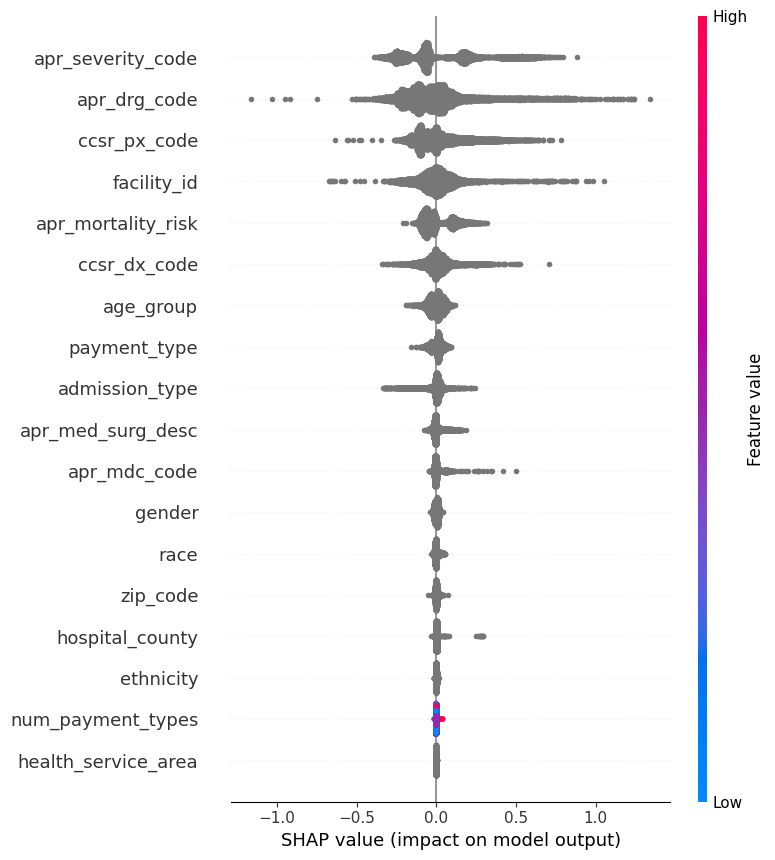

In [6]:
#Sample size
sample_idx = np.random.choice(X.index, size=10000, replace=False)
X_sample = X.loc[sample_idx]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

# Summary plot of how each feature affects model’s predictions
shap.summary_plot(shap_values, X_sample)

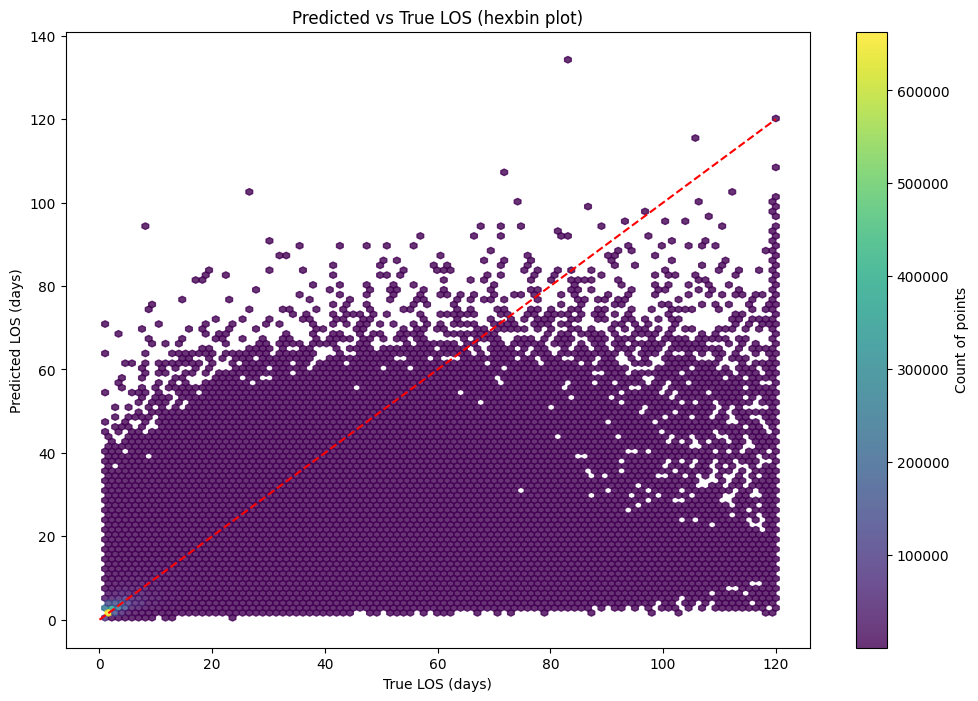

In [7]:
#Can see where the model over or under predicts LOS
# True vs predicted LOS
y_true = data['length_of_stay'].values
y_pred_log = model.predict(X)
y_pred = np.expm1(y_pred_log)

plt.figure(figsize=(12, 8))

plt.hexbin(y_true, y_pred, gridsize=100, cmap='viridis', mincnt=1, alpha=0.8)
plt.plot([0, max(y_true)], [0, max(y_true)], color='red', linestyle='--')


plt.xlabel("True LOS (days)")
plt.ylabel("Predicted LOS (days)")
plt.title("Predicted vs True LOS (hexbin plot)")
cb = plt.colorbar()
cb.set_label('Count of points')
plt.show()

In [8]:
#Overfitting:

#Predict on Test & Training set
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

#Reverse log-transformation
y_test_pred_original = np.expm1(y_test_pred)
y_test_true = np.expm1(y_test)
y_train_pred_original = np.expm1(y_train_pred)
y_train_true = np.expm1(y_train)

#Calculate metrics for Test & Train sets
test_mae = mean_absolute_error(y_test_true, y_test_pred_original)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred_original))
test_r2 = r2_score(y_test_true, y_test_pred_original)

train_mae = mean_absolute_error(y_train_true, y_train_pred_original)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred_original))
train_r2 = r2_score(y_train_true, y_train_pred_original)

#Data Results
print("\nTraining Set:")
print(f"  MAE:  {train_mae:.3f} days")
print(f"  RMSE: {train_rmse:.3f} days")
print(f"  R²:   {train_r2:.3f}")

print("\nTest Set:")
print(f"  MAE:  {test_mae:.3f} days")
print(f"  RMSE: {test_rmse:.3f} days")
print(f"  R²:   {test_r2:.3f}")

#Calculate gaps of Test & Train
mae_gap = test_mae - train_mae
rmse_gap = test_rmse - train_rmse
r2_gap = train_r2 - test_r2

print("\nOverfitting Indicators:")
print(f"  MAE gap:  {mae_gap:+.3f} days ({(mae_gap/train_mae)*100:+.1f}%)")
print(f"  RMSE gap: {rmse_gap:+.3f} days ({(rmse_gap/train_rmse)*100:+.1f}%)")
print(f"  R² gap:   {r2_gap:+.3f} ({(r2_gap/train_r2)*100:+.1f}%)")

#Verdict
if mae_gap < 0.2 and r2_gap < 0.02:
    print("No Overfitting - Model generalizes well!")
elif mae_gap < 0.5 and r2_gap < 0.05:
    print("Minimal Overfitting - Acceptable for production")
elif mae_gap < 1.0 and r2_gap < 0.10:
    print("Moderate Overfitting - Consider regularization")
else:
    print("Significant Overfitting - Model needs adjustment")



Training Set:
  MAE:  2.708 days
  RMSE: 6.548 days
  R²:   0.436

Test Set:
  MAE:  2.775 days
  RMSE: 6.731 days
  R²:   0.410

Overfitting Indicators:
  MAE gap:  +0.066 days (+2.5%)
  RMSE gap: +0.182 days (+2.8%)
  R² gap:   +0.026 (+6.0%)
Minimal Overfitting - Acceptable for production


In [9]:
#Saving Model
model.booster_.save_model("/content/drive/MyDrive/lightgbm_model.txt")